# Introduction

This notebook focuses on feature engineering and the preparation of synthetic program evaluation datasets for subsequent analyses. The objective is to enrich project- and activity-level datasets with additional features that improve the representation of evaluation patterns and support later modelling activities.

This stage introduces simple and interpretable features derived from existing evaluation and credibility dimensions. The objective is not to increase model complexity, but to identify which types of information provide additional value for understanding project and activity characteristics within a controlled simulation context.

The analysis is organized across three levels: activity, project, and higher-level constructs. All results should be interpreted within the limits of the simulation design and are intended to support methodological exploration rather than real-world inference.

## 1-Data Loading and Overview

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# Lists is excluded because it only contains UI dropdown reference values
# and does not represent analytical or machine learning–relevant data.

file_path = "/kaggle/input/datasets/jfjutras07/data-ml-dataset/4-Data_ML_Dataset.xlsx"

xls = pd.ExcelFile(file_path)
sheet_names = [s for s in xls.sheet_names if s != "Lists"]

dataframes = {}

for sheet in sheet_names:
    dataframes[sheet] = pd.read_excel(xls, sheet_name=sheet)

overview = pd.DataFrame({
    "table_name": sheet_names,
    "n_rows": [dataframes[s].shape[0] for s in sheet_names],
    "n_cols": [dataframes[s].shape[1] for s in sheet_names]
})

overview

,table_name,n_rows,n_cols
0,Project_ML,50,87
1,Activity_ML,196,21


## 2-Correlation Analysis of Project-Level Features

Before introducing additional engineered variables, the existing aggregated features are examined to identify potential redundancy between statistical descriptors. Since each evaluation dimension is initially represented through multiple measures (mean, standard deviation, minimum, maximum, and median), correlation analysis is used to determine whether some descriptors provide similar information. This step is conducted on the project-level dataset, where activity and evaluation data have already been aggregated, to support later feature selection and simplification.

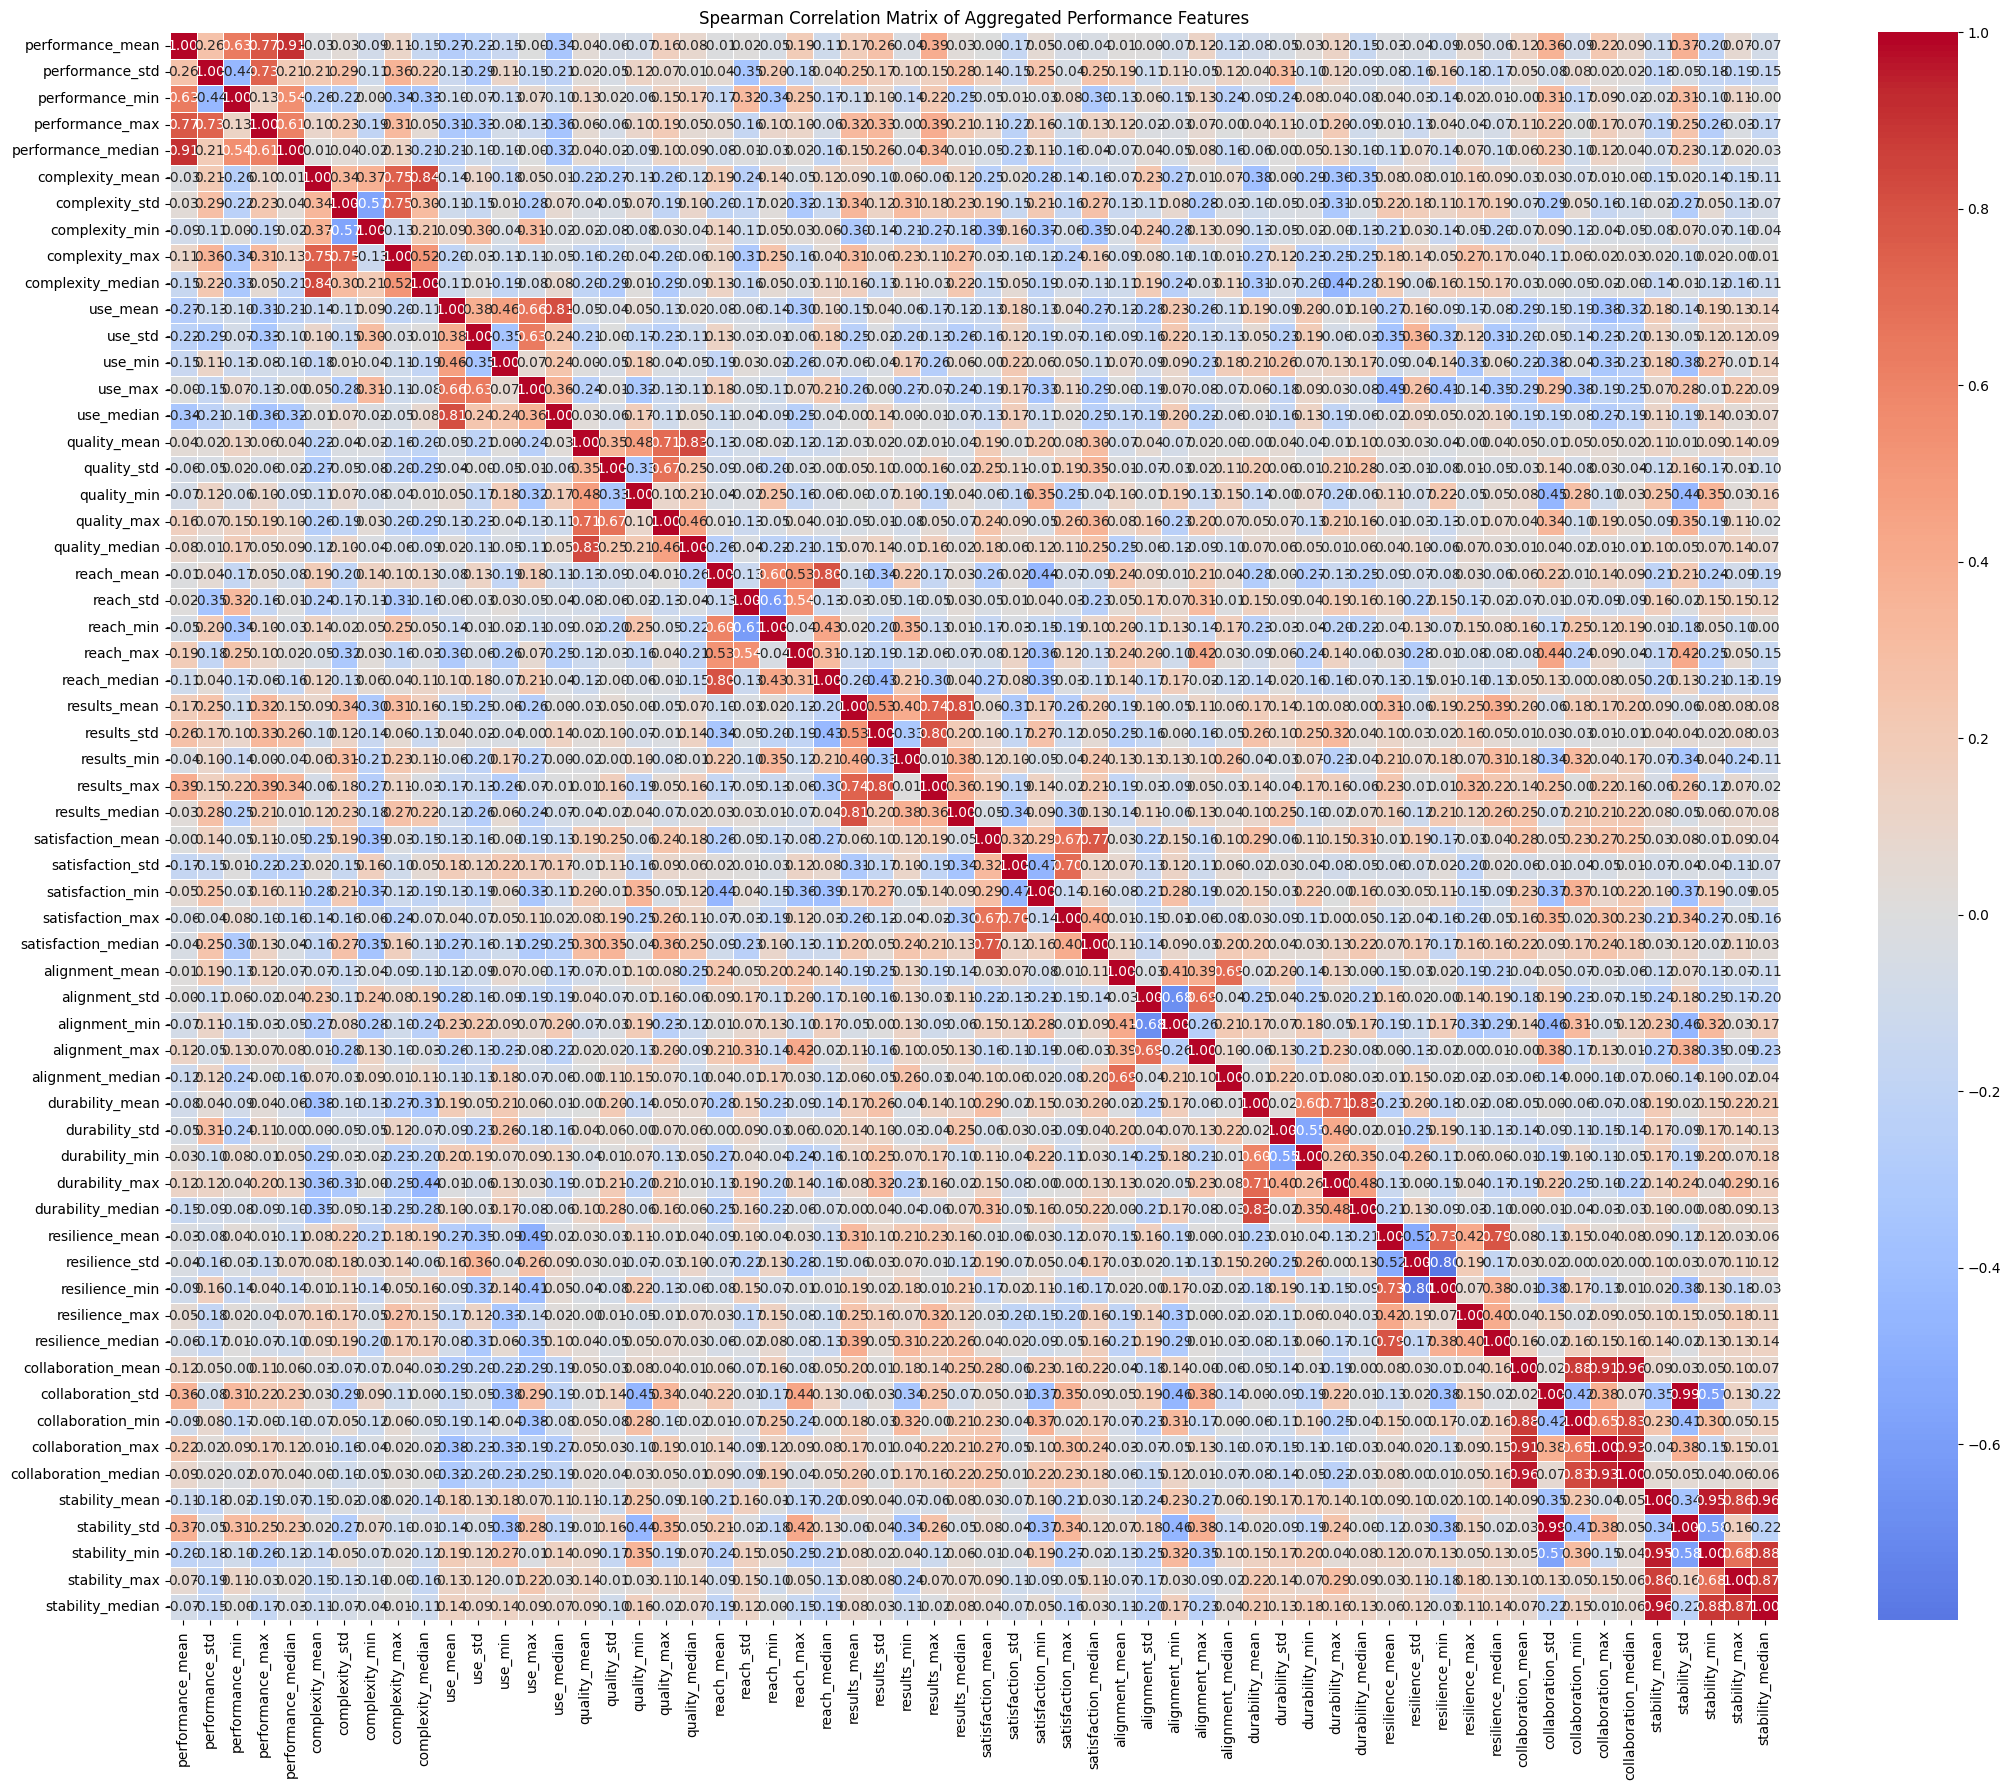

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dataframe naming
df_project = dataframes["Project_ML"].copy()
df_activity = dataframes["Activity_ML"].copy()

# Aggregated performance score descriptors
score_cols = [
    "performance_mean", "performance_std", "performance_min", "performance_max", "performance_median",
    "complexity_mean", "complexity_std", "complexity_min", "complexity_max", "complexity_median",
    "use_mean", "use_std", "use_min", "use_max", "use_median",
    "quality_mean", "quality_std", "quality_min", "quality_max", "quality_median",
    "reach_mean", "reach_std", "reach_min", "reach_max", "reach_median",
    "results_mean", "results_std", "results_min", "results_max", "results_median",
    "satisfaction_mean", "satisfaction_std", "satisfaction_min", "satisfaction_max", "satisfaction_median",
    "alignment_mean", "alignment_std", "alignment_min", "alignment_max", "alignment_median",
    "durability_mean", "durability_std", "durability_min", "durability_max", "durability_median",
    "resilience_mean", "resilience_std", "resilience_min", "resilience_max", "resilience_median",
    "collaboration_mean", "collaboration_std", "collaboration_min", "collaboration_max", "collaboration_median",
    "stability_mean", "stability_std", "stability_min", "stability_max", "stability_median"
]

corr = df_project[score_cols].corr(method="spearman")

plt.figure(figsize=(22, 18))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix of Aggregated Performance Features")
plt.tight_layout()
plt.show()

The correlation analysis indicates redundancy between several statistical descriptors, particularly within the same dimensions. Measures such as mean, median, minimum, and maximum often show similar patterns, suggesting that they may capture overlapping information. These results support the development of a more compact feature representation by reducing unnecessary duplication while preserving the main analytical signals.

## 3-Construction of Variability Features and Redundancy Analysis

This section introduces additional features to further describe the evaluation dimensions. The previous correlation analysis showed that some statistical descriptors provide similar information. However, variability measures can still provide useful information by describing how consistent or dispersed the underlying observations are.

To capture this aspect, two additional indicators are created for each dimension: range, which represents the difference between the minimum and maximum values, and standard deviation, which measures the dispersion around the mean. These features complement the existing aggregated measures by providing additional information about the variation of project characteristics.

In [3]:
dimensions = [
    "performance",
    "complexity",
    "use",
    "quality",
    "reach",
    "results",
    "satisfaction",
    "alignment",
    "durability",
    "resilience",
    "collaboration",
    "stability"
]

for d in dimensions:
    df_project[f"{d}_range"] = (
        df_project[f"{d}_max"] -
        df_project[f"{d}_min"]
    )

    df_project[f"{d}_variability"] = (
        df_project[f"{d}_std"] /
        df_project[f"{d}_mean"]
    ).fillna(0)

df_project.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Columns: 111 entries, id_project to stability_variability
dtypes: float64(52), int64(47), object(12)
memory usage: 43.5+ KB


After introducing these additional features, redundancy is reassessed because multiple summary statistics and variability measures are now included in the dataset.

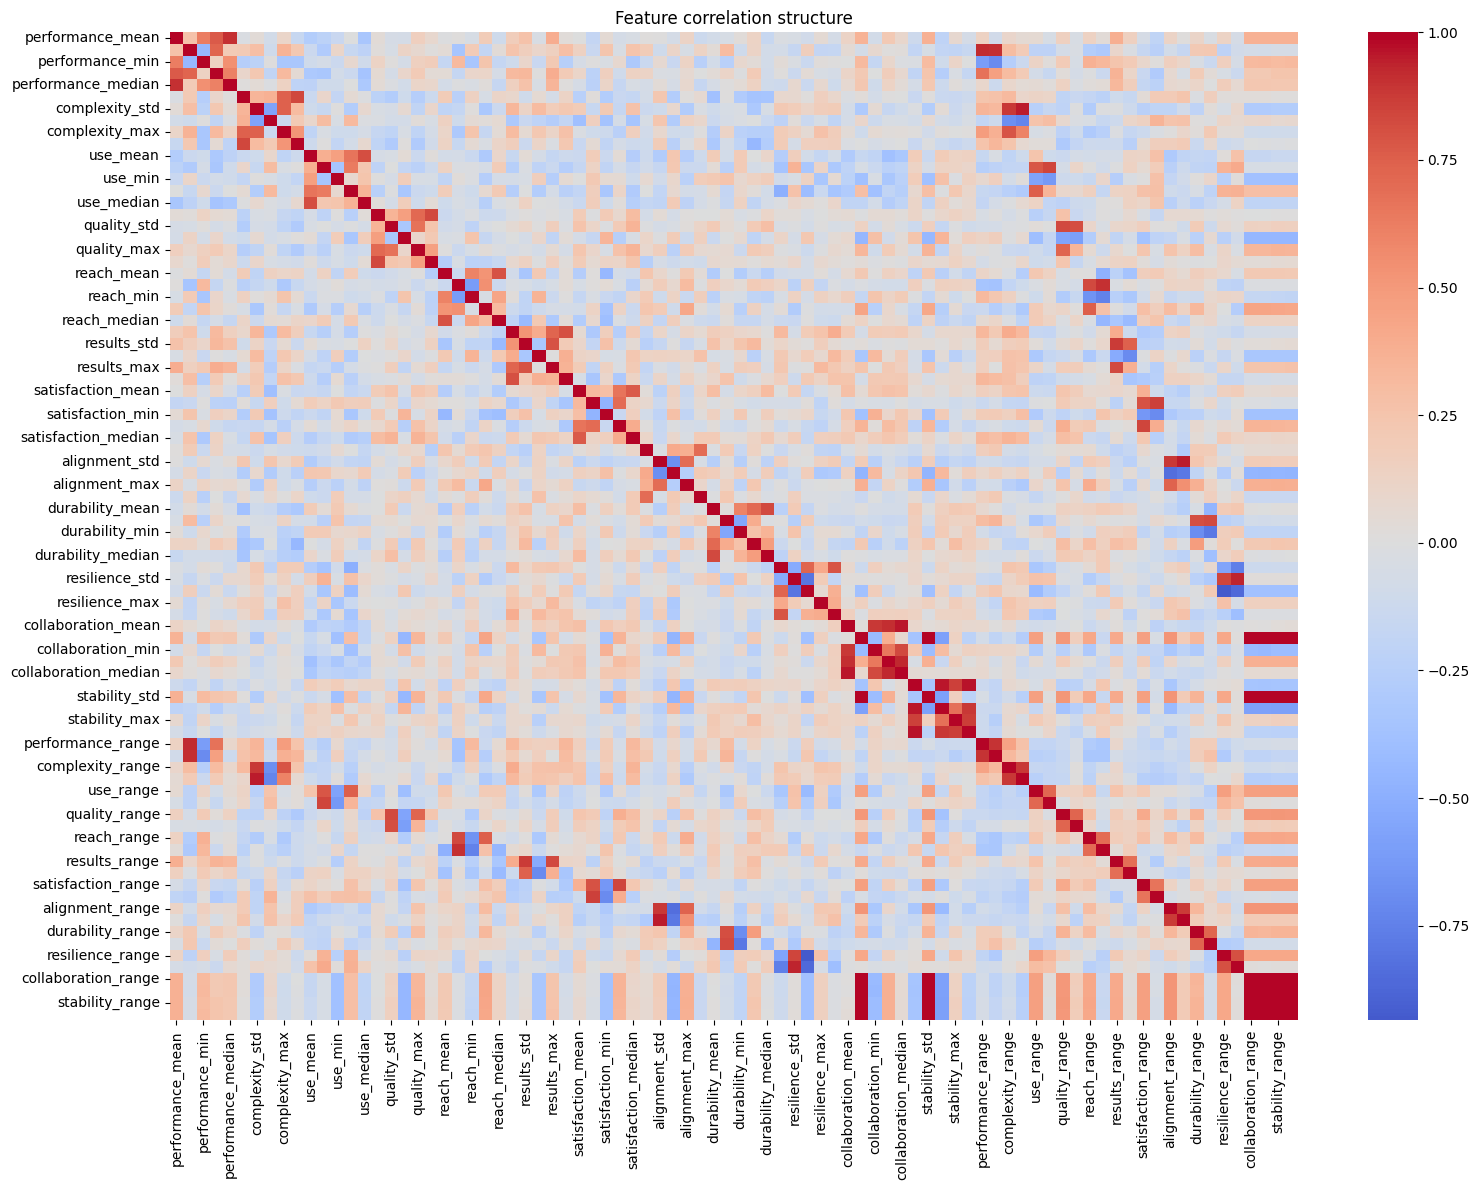

In [4]:
feature_cols = [c for c in df_project.columns 
                if any(x in c for x in [
                    "_mean", "_std", "_min", "_max", "_median",
                    "_range", "_variability"
                ])]

df_corr = df_project[feature_cols].corr(method="spearman")

plt.figure(figsize=(16, 12))
sns.heatmap(df_corr, cmap="coolwarm", center=0)
plt.title("Feature correlation structure")
plt.tight_layout()
plt.show()

The results confirm redundancy across several statistical descriptors. Dispersion-based features such as range and variability show similar patterns with standard deviation, while central tendency measures remain strongly related. These results support the simplification of the feature set by grouping related information and reducing unnecessary duplication while preserving the main analytical information.

For modelling purposes, only the variability measure is retained as the dispersion indicator. In this simulation context, it provides a more consistent representation of data spread, while range is more influenced by extreme values.

In [5]:
# Remove range features (keep variability only)

range_cols = [c for c in df_project.columns if c.endswith("_range")]

df_project = df_project.drop(columns=range_cols)

df_project.shape

(50, 99)

## 4-Construction of Composite Evaluation Dimensions

To support higher-level interpretation, evaluation features are grouped into composite indicators inspired by OECD-DAC evaluation concepts and aligned with the project evaluation dimensions identified in the literature. These indicators are not directly observed variables, but simplified analytical constructs designed to summarize related dimensions across activity and project levels.

- Efficiency combines the aggregated performance and complexity dimensions. Performance is derived from cost and time, while complexity is derived from novelty and effort, providing an overall indicator of the relationship between project demands and achieved outputs.

- Effectiveness combines use and quality, capturing how outputs are used and how well they respond to identified needs.

- Impact combines reach and results, representing the extent of influence and outcomes generated by the intervention.

- Relevance combines satisfaction and alignment, reflecting perceived adequacy and consistency with project objectives.

- Sustainability combines durability and resilience, capturing the persistence of results over time and the capacity to adapt to changing conditions.

- Coherence combines collaboration and stability, where collaboration reflects coordination between actors and stability reflects internal organizational continuity.

These composite indicators are calculated using equal weighting between their component dimensions. This approach is used as a transparent simplifying assumption within the simulation context, allowing the creation of interpretable higher-level indicators while maintaining consistency across dimensions.

In [6]:
# OECD-DAC composites (program-level)

pairs = {
    "efficiency": ("performance_mean", "complexity_mean"),
    "effectiveness": ("use_mean", "quality_mean"),
    "impact": ("reach_mean", "results_mean"),
    "relevance": ("satisfaction_mean", "alignment_mean"),
    "sustainability": ("durability_mean", "resilience_mean"),
    "coherence": ("collaboration_mean", "stability_mean")
}

for k, (a, b) in pairs.items():
    df_project[k] = (df_project[a] + df_project[b]) / 2

df_project[list(pairs.keys())].describe()

,efficiency,effectiveness,impact,relevance,sustainability,coherence
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,2.348345,2.739400,2.761029,2.972343,3.466543,3.770000
std,0.241508,0.333867,0.333172,0.275990,0.326215,0.589794
min,1.833333,2.100000,2.000000,2.300000,2.600000,2.500000
25%,2.218750,2.587500,2.587500,2.800000,3.300000,3.500000
50%,2.333333,2.700000,2.790000,3.000000,3.500000,3.800000
75%,2.500000,2.900000,2.915000,3.100000,3.600000,4.000000
max,3.000000,3.600000,3.400000,3.750000,4.400000,5.000000


These composite indicators show coherent internal distributions with differentiated central tendencies across dimensions. Efficiency presents the lowest average value, reflecting lower combined levels of cost, time, novelty, and effort within the simulated projects. In this context, higher efficiency values should not be interpreted as better performance, but rather as greater operational demands and complexity associated with project implementation.

Effectiveness and impact show similar central tendencies and variability, indicating consistent structures between the utilization and quality of outputs, and the reach and results generated by projects. Relevance presents a relatively stable distribution, reflecting consistent alignment and satisfaction patterns across projects. Sustainability displays higher average values, suggesting stronger simulated scores related to durability and resilience. Coherence presents the highest mean and variability, reflecting the broader range introduced by collaboration and stability dimensions.

Overall, the composite indicators remain consistent with the conceptual relationships established in the framework. Their interpretation depends on the direction of each construct, particularly for efficiency, where higher values represent greater operational complexity rather than improved outcomes.

In [7]:
# Check redundancy between composite OECD-DAC indicators (Spearman correlation)
comp_cols = list(pairs.keys())
df_project[comp_cols].corr(method="spearman")

,efficiency,effectiveness,impact,relevance,sustainability,coherence
efficiency,1.000000,-0.275666,0.304364,-0.202487,-0.206238,-0.108567
effectiveness,-0.275666,1.000000,-0.187541,-0.056554,-0.046107,-0.032497
impact,0.304364,-0.187541,1.000000,-0.036694,0.042752,0.033749
relevance,-0.202487,-0.056554,-0.036694,1.000000,0.116153,0.066341
sustainability,-0.206238,-0.046107,0.042752,0.116153,1.000000,0.224599
coherence,-0.108567,-0.032497,0.033749,0.066341,0.224599,1.000000


The composite indicators show generally low inter-correlations, indicating that each construct captures a distinct aspect of the evaluation framework. The limited relationships observed between dimensions suggest that the indicators provide complementary information rather than measuring the same underlying pattern. This supports their use as separate but related higher-level analytical constructs within the subsequent modelling steps.

In [8]:
print(df_project.shape)
print(df_activity.shape)

(50, 105)
(196, 21)


## 5-Conclusion

This feature engineering stage brings the dataset to a more structured and interpretable form by introducing additional variability measures and higher-level composite indicators. The comparison between range and variability indicates that both features capture similar information, with variability being retained as the preferred dispersion indicator because it provides a more stable representation that is less sensitive to extreme values.

The composite indicators show coherent patterns within this controlled simulation context, although their interpretation should remain cautious given the synthetic nature of the data. These relationships and levels of consistency may differ in the research dataset, where greater noise, heterogeneity, and contextual variation are expected.

These transformations improve the interpretability of the dataset while preserving the main analytical information. They provide a practical and structured feature set for the subsequent modelling and encoding stages.

## 6-Data Export

In [9]:
import os

# Define export path
export_path = "/kaggle/working/"
excel_file = "simulation_fe_datasets.xlsx"
excel_path = os.path.join(export_path, excel_file)

# Ensure directory exists
os.makedirs(export_path, exist_ok=True)

# Define datasets to export
tables_to_export = {
    "Project_FE": df_project,
    "Activity_FE": df_activity
}

# Export into a single Excel file
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables_to_export.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

# Validation
print(f"FE datasets successfully created: {excel_path}")

FE datasets successfully created: /kaggle/working/simulation_fe_datasets.xlsx
